## COMSOL Lead Field → 전기장 크기 계산

**컬럼 구조**: `x, y, Ex@idx=1(복소수), Ey@idx=1, Ex@idx=2, Ey@idx=2`  
**원리**: Anti-phase 채널 전기장 = `E_idx1 - E_idx2` (실수부 사용) → `|E| = sqrt(Ex² + Ey²)`

참고 코드: `KDY_optimization_electrode_origin.ipynb` — `load_leadfield_data`, `compute_AM_Grossman`

In [489]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from pathlib import Path
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata
from scipy.spatial import cKDTree


# 한글 폰트 설정 (Windows: Malgun Gothic)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

In [490]:
import re

SIM_DIR = Path(r"D:\00_Project\nTIS\docs\07_Simulation\Result")

# 공통 파일명 접두어 (X, Y 조건까지 포함) — 이 부분만 조건 바꿀 때마다 수정
# 예: "COMSOL_Efield_CompactXY_X30_Y30" → 실제 파일명: "..._leadField_f1.csv" / "..._leadField_f2.csv" / "..._AM_vector.csv"
BASE_NAME = "COMSOL_Efield_CompactY_X50_Y10"

# f1 lead field 파일 (채널 1: 전극 1,2)
LEADFIELD_F1 = SIM_DIR / f"{BASE_NAME}_leadField_f1.csv"
# f2 lead field 파일 (채널 2: 전극 3,4)
LEADFIELD_F2 = SIM_DIR / f"{BASE_NAME}_leadField_f2.csv"
# 검증용 파일 (COMSOL AM_vector surface export — steady-state 전체 노드)
AM_VECTOR_FILE = SIM_DIR / f"{BASE_NAME}_AM_vector.csv"

CURRENT_F1_MA = 1.0   # 채널 1 (전극 1,2) 인가 전류 [mA]
CURRENT_F2_MA = 1.0   # 채널 2 (전극 3,4) 인가 전류 [mA]

# ── 조건 태그 추출 (예: "COMSOL_Efield_Base_X50_Y50" → "Base_X50_Y50") ──
# 결과 파일명에 붙여서, 조건(X/Y)이 다른 데이터로 실행할 때마다 결과가 따로 저장되게 한다.
_tag_match = re.match(r"^COMSOL_Efield_(.+)$", BASE_NAME)
TAG = _tag_match.group(1) if _tag_match else BASE_NAME

print(f"f1 lead field: {LEADFIELD_F1.name}  존재: {LEADFIELD_F1.exists()}")
print(f"f2 lead field: {LEADFIELD_F2.name}  존재: {LEADFIELD_F2.exists()}")
print(f"AM_vector file: {AM_VECTOR_FILE.name}  존재: {AM_VECTOR_FILE.exists()}")
print(f"전류 — Ch1: {CURRENT_F1_MA} mA  /  Ch2: {CURRENT_F2_MA} mA")
print(f"조건 태그 (TAG): {TAG}")

# ── 파일 존재 확인: 하나라도 없으면 즉시 중단 (다음 셀 진행 방지) ──
_missing = [p for p in (LEADFIELD_F1, LEADFIELD_F2, AM_VECTOR_FILE) if not p.exists()]
if _missing:
    raise FileNotFoundError(
        "다음 파일을 찾을 수 없습니다 — BASE_NAME 또는 SIM_DIR을 확인하세요:\n"
        + "\n".join(f"  - {p}" for p in _missing)
    )


f1 lead field: COMSOL_Efield_CompactY_X50_Y10_leadField_f1.csv  존재: True
f2 lead field: COMSOL_Efield_CompactY_X50_Y10_leadField_f2.csv  존재: True
AM_vector file: COMSOL_Efield_CompactY_X50_Y10_AM_vector.csv  존재: True
전류 — Ch1: 1.0 mA  /  Ch2: 1.0 mA
조건 태그 (TAG): CompactY_X50_Y10


### 1. 데이터 로드

KDY `load_leadfield_data` 기반 — 2D(Ex, Ey)용으로 수정.

반환 형태:
- `coords`: `(N, 2)` — x, y 좌표 [mm]
- `E_tensor`: `(num_electrodes, N, 2)` — 각 전극의 [Ex, Ey] [V/m, 실수부]

In [491]:
def load_leadfield_2d(filepath, x_range=None, y_range=None):
    """
    COMSOL 2D lead field CSV 로드.
    - x_range/y_range=None 이면 데이터에서 도메인 자동 판단
    - NaN 행 제거
    - 준정적 전기장이므로 실수부만 사용 (허수부 ~1.5% 무시)
    반환: coords (N, 2), E_tensor (num_electrodes, N, 2)
    """
    print(f"Loading: {Path(filepath).name}")
    df = pd.read_csv(filepath, comment='%', header=None)

    # NaN 행 제거
    n_before = len(df)
    df = df.dropna().reset_index(drop=True)
    if len(df) < n_before:
        print(f"  [!] NaN 행 제거: {n_before - len(df)}개")

    cx = df.iloc[:, 0].values.astype(float)
    cy = df.iloc[:, 1].values.astype(float)

    # 도메인 자동 판단 (None이면 데이터 범위 그대로 사용)
    if x_range is None:
        x_range = (float(cx.min()), float(cx.max()))
    if y_range is None:
        y_range = (float(cy.min()), float(cy.max()))
    print(f"  도메인 — x: [{x_range[0]:.2f}, {x_range[1]:.2f}] mm  "
          f"y: [{y_range[0]:.2f}, {y_range[1]:.2f}] mm")

    # 좌표 범위 필터링
    mask = (
        (cx >= x_range[0]) & (cx <= x_range[1]) &
        (cy >= y_range[0]) & (cy <= y_range[1])
    )
    if (~mask).sum():
        print(f"  [!] 범위 밖 노드 제거: {(~mask).sum()}개")
    df = df[mask].reset_index(drop=True)

    coords     = df.iloc[:, :2].values.astype(float)
    field_cols = df.iloc[:, 2:]
    num_electrodes = field_cols.shape[1] // 2
    num_points     = len(df)

    # 복소수 파싱: 'i' → 'j', 실수부 추출
    parsed = np.zeros((num_points, field_cols.shape[1]), dtype=np.float64)
    for i in range(field_cols.shape[1]):
        col_str = (field_cols.iloc[:, i]
                   .fillna('0').astype(str)
                   .str.replace(' ', '', regex=False)
                   .str.replace('i', 'j', regex=False))
        parsed[:, i] = np.real(np.array([complex(v) for v in col_str]))

    E_tensor = np.zeros((num_electrodes, num_points, 2))
    for e in range(num_electrodes):
        E_tensor[e, :, 0] = parsed[:, e * 2]
        E_tensor[e, :, 1] = parsed[:, e * 2 + 1]

    print(f"  → 전극 {num_electrodes}개 / 유효 포인트 {num_points}개 / E_tensor: {E_tensor.shape}")
    return coords, E_tensor


coords, E_f1 = load_leadfield_2d(LEADFIELD_F1)
_,      E_f2 = load_leadfield_2d(LEADFIELD_F2)

x, y = coords[:, 0], coords[:, 1]
print(f"\n좌표 범위 — x: [{x.min():.2f}, {x.max():.2f}] mm  "
      f"y: [{y.min():.2f}, {y.max():.2f}] mm")

Loading: COMSOL_Efield_CompactY_X50_Y10_leadField_f1.csv
  [!] NaN 행 제거: 1116개
  도메인 — x: [-25.00, 25.00] mm  y: [-5.00, 5.00] mm
  → 전극 2개 / 유효 포인트 451개 / E_tensor: (2, 451, 2)
Loading: COMSOL_Efield_CompactY_X50_Y10_leadField_f2.csv
  [!] NaN 행 제거: 1116개
  도메인 — x: [-25.00, 25.00] mm  y: [-5.00, 5.00] mm
  → 전극 2개 / 유효 포인트 451개 / E_tensor: (2, 451, 2)

좌표 범위 — x: [-25.00, 25.00] mm  y: [-5.00, 5.00] mm


### 2. Anti-phase 채널 전기장 합성 & 크기 계산

각 파일의 두 전극(idx=1, idx=2)이 서로 **anti-phase** 쌍이므로 차분으로 채널 전기장 합성. (KDY 코드 루프 내 `Ef = E[a] - E[b]` 와 동일한 원리.)

$$\mathbf{E}_{ch} = \mathbf{E}_{idx=1} - \mathbf{E}_{idx=2}$$

$$|\mathbf{E}| = \sqrt{E_x^2 + E_y^2}$$

> **Note:** COMSOL Terminal이 이미 `1[mA]`로 계산 → CSV 값이 V/m @ 1mA.  별도 전류 스케일링 불필요.

In [492]:
# ── Anti-phase 채널 전기장 합성 ───────────────────────────────────────────────
# COMSOL Terminal = 1[mA]로 계산 → CSV already in V/m @ 1mA → 별도 스케일 불필요
Ef1 = E_f1[0] - E_f1[1]   # (N, 2): [Ex_f1, Ey_f1] [V/m]
Ef2 = E_f2[0] - E_f2[1]   # (N, 2): [Ex_f2, Ey_f2] [V/m]

print(f"Ef1 shape: {Ef1.shape}  (채널 1: 전극 1,2 / {CURRENT_F1_MA} mA)")
print(f"Ef2 shape: {Ef2.shape}  (채널 2: 전극 3,4 / {CURRENT_F2_MA} mA)")

# ── 전기장 크기 계산 ──────────────────────────────────────────────────────────
E_mag_f1 = np.linalg.norm(Ef1, axis=1)   # (N,) [V/m]
E_mag_f2 = np.linalg.norm(Ef2, axis=1)   # (N,) [V/m]

print("\n── |E_f1| 통계 (V/m) ──")
print(f"  max={E_mag_f1.max():.6f}  mean={E_mag_f1.mean():.6f}  median={np.median(E_mag_f1):.6f}")
print("── |E_f2| 통계 (V/m) ──")
print(f"  max={E_mag_f2.max():.6f}  mean={E_mag_f2.mean():.6f}  median={np.median(E_mag_f2):.6f}")

Ef1 shape: (451, 2)  (채널 1: 전극 1,2 / 1.0 mA)
Ef2 shape: (451, 2)  (채널 2: 전극 3,4 / 1.0 mA)

── |E_f1| 통계 (V/m) ──
  max=0.127044  mean=0.030116  median=0.000172
── |E_f2| 통계 (V/m) ──
  max=0.127459  mean=0.030435  median=0.000284


### 3. AM Modulation 계산 (Grossman 2017)

두 채널 전기장이 조직 내에서 간섭할 때 생기는 저주파 envelope.

$$AM_{max} = \max_{\hat{n}} \left[ 2 \cdot \min\left(|\mathbf{E}_{f1} \cdot \hat{n}|,\ |\mathbf{E}_{f2} \cdot \hat{n}|\right) \right]$$

`compute_AM_Grossman` — KDY `KDY_optimization_electrode_origin.ipynb` 에서 가져옴 (2D 그대로 적용 가능).

In [493]:
def compute_AM_Grossman(Ef1, Ef2):
    """
    Grossman 2017 AM modulation 계산.
    Ef1, Ef2: shape (N, 2) or (N, 3) — 각 채널의 전기장 벡터
    반환: AM_vector (N,) — 각 포인트의 AM envelope 크기 [V/m]
    """
    eps = 1e-15

    n1 = np.linalg.norm(Ef1, axis=1)
    n2 = np.linalg.norm(Ef2, axis=1)
    n1 = np.where(n1 == 0, eps, n1)
    n2 = np.where(n2 == 0, eps, n2)

    # 크기 기준으로 E_max / E_min 분류
    cond   = n1 > n2
    E_max  = np.where(cond[:, None], Ef1, Ef2)
    E_min  = np.where(cond[:, None], Ef2, Ef1)
    E1_amp = np.where(cond, n1, n2)
    E2_amp = np.where(cond, n2, n1)

    # 두 벡터 사이 각도
    dot_prod = np.sum(E_max * E_min, axis=1)
    cosB     = np.clip(dot_prod / (E1_amp * E2_amp), -1.0, 1.0)
    ang      = np.arccos(cosB)

    # 예각/둔각 분기
    acute_cond  = ang < (np.pi / 2)
    E_min_adj   = np.where(acute_cond[:, None], E_min, -E_min)
    cosA        = np.where(acute_cond, cosB, -cosB)

    E_m      = E_max - E_min_adj
    norm_E_m = np.linalg.norm(E_m, axis=1)
    norm_E_m = np.where(norm_E_m == 0, eps, norm_E_m)

    dot_max_min_adj = np.sum(E_max * E_min_adj, axis=1)
    cosBB = np.clip((-(E2_amp**2) + dot_max_min_adj) / (E2_amp * norm_E_m), -1.0, 1.0)
    sinBB = np.sin(np.arccos(cosBB))

    am_cond   = E2_amp < (E1_amp * cosA)
    AM_vector = np.where(am_cond, 2 * E2_amp, 2 * E2_amp * sinBB)

    return AM_vector


AM_max = compute_AM_Grossman(Ef1, Ef2)   # (N,) [V/m]

print("── AM_max 통계 (V/m) ──")
print(f"  max={AM_max.max():.8f}  mean={AM_max.mean():.8f}  median={np.median(AM_max):.8f}")


df_result = pd.DataFrame({
    "x (mm)"       : x,
    "y (mm)"       : y,
    "Ex_f1 (V/m)"  : Ef1[:, 0],
    "Ey_f1 (V/m)"  : Ef1[:, 1],
    "|E_f1| (V/m)" : E_mag_f1,
    "Ex_f2 (V/m)"  : Ef2[:, 0],
    "Ey_f2 (V/m)"  : Ef2[:, 1],
    "|E_f2| (V/m)" : E_mag_f2,
    "AM_max (V/m)" : AM_max,
})

#df_result.sort_values("AM_max (V/m)", ascending=False).head(10).reset_index(drop=True)
df_result.describe()

── AM_max 통계 (V/m) ──
  max=0.00042106  mean=0.00001773  median=0.00000120


,x (mm),y (mm),Ex_f1 (V/m),Ey_f1 (V/m),|E_f1| (V/m),Ex_f2 (V/m),Ey_f2 (V/m),|E_f2| (V/m),AM_max (V/m)
count,451.000000,451.000000,4.510000e+02,4.510000e+02,4.510000e+02,4.510000e+02,4.510000e+02,4.510000e+02,4.510000e+02
mean,0.070531,0.025223,-5.317282e-04,-2.291446e-02,3.011608e-02,-7.353674e-04,-2.316004e-02,3.043507e-02,1.773485e-05
std,18.767676,3.158564,2.711812e-02,3.336142e-02,3.828715e-02,2.744585e-02,3.327398e-02,3.834321e-02,6.125537e-05
min,-25.000000,-5.000000,-9.887191e-02,-1.270427e-01,9.116514e-10,-9.888484e-02,-1.274581e-01,7.554477e-10,1.510895e-09
25%,-19.021852,-2.918379,-1.561816e-04,-4.735812e-02,6.044088e-07,-2.303309e-04,-4.740202e-02,5.870844e-07,8.883862e-07
50%,0.907097,-0.085785,-2.241848e-09,-5.997661e-06,1.722137e-04,-1.036482e-09,-1.771592e-05,2.843491e-04,1.201962e-06
75%,18.910372,2.999187,3.988284e-05,-3.570049e-07,6.733050e-02,6.038327e-05,-3.536709e-07,6.728809e-02,3.165065e-06
max,25.000000,5.000000,9.934543e-02,1.640231e-04,1.270435e-01,9.935540e-02,1.838650e-04,1.274588e-01,4.210602e-04


### 4. 시각화 — 공간 분포

팬텀 크기: 50 x 10 mm  /  전극 좌표(1사분면): (20, 5) mm
Saved: D:\00_Project\nTIS\docs\07_Simulation\Result\Result_Efield_am_map_CompactY_X50_Y10.png


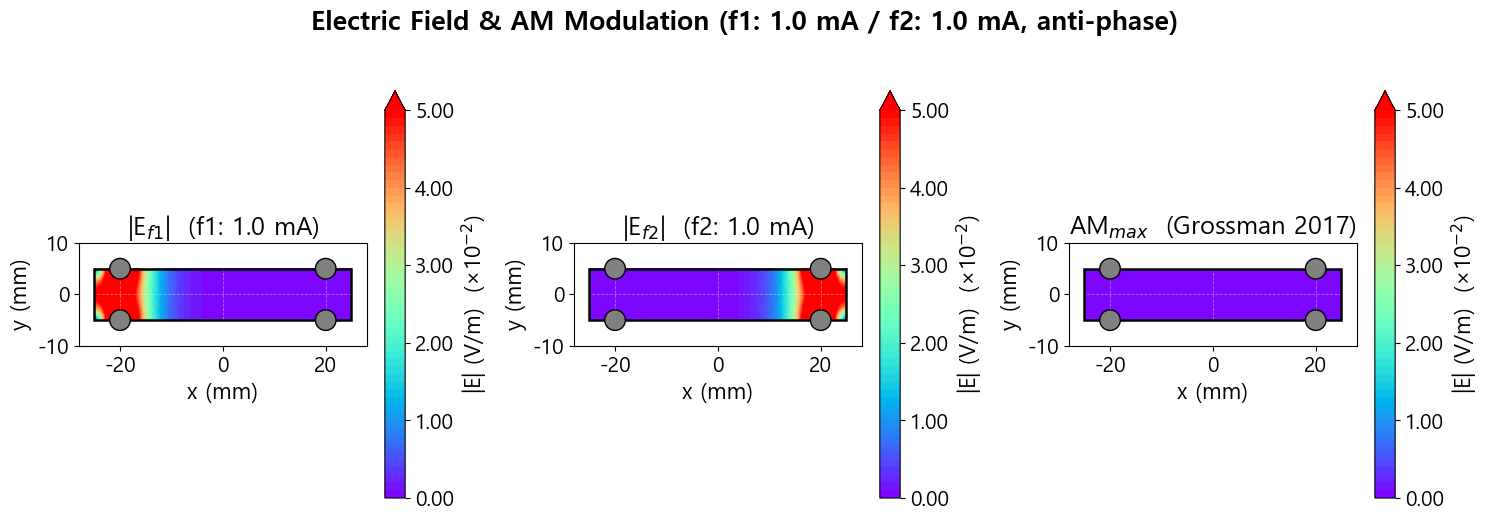

In [494]:
# ── 전극 좌표 / 팬텀 geometry (시각화용, 사용자 실측값 mm) — 이 셀에서만 정의 ──
# key: (X_mm, Y_mm) 팬텀 크기 → value: 1사분면 전극 좌표 (ex, ey)
# 나머지 3개 전극은 x/y축 대칭: (-ex,ey), (ex,-ey), (-ex,-ey)
ELECTRODE_XY_TABLE = {
    (50, 50): (25, 20),
    (30, 50): (15, 20),
    (10, 50): (5, 20),
    (50, 30): (20, 15),
    (50, 10): (20, 5),
    (30, 30): (15, 10),
    (10, 10): (5, 2.5),
}
ELECTRODE_RADIUS_MM = 2.0   # 지름 2 mm

_xy_match = re.search(r"X(\d+)_Y(\d+)$", TAG)
if _xy_match is None:
    raise ValueError(f"TAG '{TAG}'에서 X##_Y## 패턴을 찾을 수 없습니다.")
PHANTOM_X_MM, PHANTOM_Y_MM = int(_xy_match.group(1)), int(_xy_match.group(2))

if (PHANTOM_X_MM, PHANTOM_Y_MM) not in ELECTRODE_XY_TABLE:
    raise KeyError(
        f"팬텀 크기 ({PHANTOM_X_MM}, {PHANTOM_Y_MM})에 대한 전극 좌표가 "
        f"ELECTRODE_XY_TABLE에 없습니다. 표를 갱신하세요."
    )
_ex, _ey = ELECTRODE_XY_TABLE[(PHANTOM_X_MM, PHANTOM_Y_MM)]

ELECTRODES = {
    "CH1 top": (-_ex,  _ey),
    "CH1 bot": (-_ex, -_ey),
    "CH2 top": ( _ex,  _ey),
    "CH2 bot": ( _ex, -_ey),
}

print(f"팬텀 크기: {PHANTOM_X_MM} x {PHANTOM_Y_MM} mm  /  전극 좌표(1사분면): ({_ex}, {_ey}) mm")

# ── 이 조건의 팬텀 + 전극이 전부 들어오는 x/y축 범위 계산 ────────────────────
# 전극이 팬텀 경계 위/밖에 걸쳐 있어도 원 전체가 잘리지 않도록, 각 축의 절반 크기를
# "팬텀 절반" vs "전극 중심 + 반지름" 중 더 큰 값으로 잡고, 여유 공간(PAD_MM)을 더한다.
PAD_MM = 3.0
FRAME_X_HALF = max(PHANTOM_X_MM / 2, _ex + ELECTRODE_RADIUS_MM) + PAD_MM
FRAME_Y_HALF = max(PHANTOM_Y_MM / 2, _ey + ELECTRODE_RADIUS_MM) + PAD_MM


def draw_geometry_overlay(ax):
    """팬텀 경계(검은 실선 사각형) + 전극(회색 원, rainbow colormap과 무관) 오버레이.

    틀(사각형)과 전극(원)만 그린다 — x/y축 범위는 전혀 건드리지 않으며, 필요하면
    호출부에서 직접 set_xlim/set_ylim으로 지정한다.
    """
    rect = plt.Rectangle(
        (-PHANTOM_X_MM / 2, -PHANTOM_Y_MM / 2), PHANTOM_X_MM, PHANTOM_Y_MM,
        fill=False, edgecolor="black", linewidth=1.8, linestyle="-", zorder=5,
    )
    ax.add_patch(rect)
    for name, (px, py) in ELECTRODES.items():
        circ = plt.Circle((px, py), ELECTRODE_RADIUS_MM,
                           facecolor="gray", edgecolor="black", linewidth=1.0, zorder=6)
        ax.add_patch(circ)


# ── Colorbar tick label을 10^-2 단위 숫자로 통일 (V/m 필드용) — 이 셀에서만 정의 ──
# ScalarFormatter의 자동 offset text는 위치가 부정확해 수동으로 tick/label을 지정한다.
def apply_sci_colorbar(cb, vmin, vmax, power=-2, n_ticks=6,
                        label_fontsize=16, tick_fontsize=15):
    """Colorbar tick을 ×10^power 단위 숫자로 표시하고 label에 배율 표기를 덧붙인다."""
    scale = 10 ** power
    ticks = np.linspace(vmin, vmax, n_ticks)
    cb.set_ticks(ticks)
    cb.set_ticklabels([f"{t / scale:.2f}" for t in ticks])
    cb.ax.tick_params(labelsize=tick_fontsize)
    base_label = cb.ax.get_ylabel().split("  (×10")[0]
    cb.set_label(f"{base_label}  (×10$^{{{power}}}$)", fontsize=label_fontsize)


triang = mtri.Triangulation(x, y)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

panels = [
    (axes[0], f"|E$_{{f1}}$|  (f1: {CURRENT_F1_MA} mA)", E_mag_f1),
    (axes[1], f"|E$_{{f2}}$|  (f2: {CURRENT_F2_MA} mA)", E_mag_f2),
    (axes[2], "AM$_{max}$  (Grossman 2017)",             AM_max),
]

VMIN, VMAX = 0, 0.05   # 조건 간 객관적 비교를 위해 colorbar range 고정

for ax, title, mag in panels:
    tcf = ax.tricontourf(triang, mag, levels=np.linspace(VMIN, VMAX, 51),
                          cmap="rainbow", vmin=VMIN, vmax=VMAX, extend="max")
    cb  = fig.colorbar(tcf, ax=ax, shrink=0.85)
    cb.set_label("|E| (V/m)", fontsize=16)
    apply_sci_colorbar(cb, VMIN, VMAX)
    cb.ax.tick_params(labelsize=15)
    ax.set_title(title, fontsize=18)
    ax.set_xlabel("x (mm)", fontsize=16)
    ax.set_ylabel("y (mm)", fontsize=16)
    ax.tick_params(labelsize=15)
    ax.set_aspect("equal")
    draw_geometry_overlay(ax)
    ax.set_xlim(-FRAME_X_HALF, FRAME_X_HALF)
    ax.set_ylim(-FRAME_Y_HALF, FRAME_Y_HALF)
    ax.grid(True, color="white", alpha=0.4, linewidth=0.6, linestyle="--", zorder=4)

fig.suptitle(
    f"Electric Field & AM Modulation "
    f"(f1: {CURRENT_F1_MA} mA / f2: {CURRENT_F2_MA} mA, anti-phase)",
    fontsize=19, fontweight="bold"
)
plt.tight_layout()
save_path = SIM_DIR / f"Result_Efield_am_map_{TAG}.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path.resolve()}")
plt.show()

### 4-1. 특정 좌표 조회 — Ef1 / Ef2 / AM 변조 벡터 상세

지정한 좌표(들)에서 f1 채널 전기장, f2 채널 전기장, AM modulation 벡터(크기 + 방향)를 표로 확인한다.

**AM 방향 정의** (`compute_AM_Grossman`의 기하 변수를 재사용해 유도, Grossman 2017 이론과 일치):
- Case A ($|E_{min}| \le |E_{max}|\cos\alpha$): 변조축은 작은 벡터 방향과 동일 → $\hat{n}_{AM} = \hat{E}_{min}$
- Case B (그 외): 변조축은 $E_{min}$ 중 $(E_{max}-E_{min})$에 수직한 성분 방향

좌표는 mesh 노드와 정확히 일치하지 않을 수 있으므로 `cKDTree`로 최근접 노드를 매칭해 값을 가져온다 (보간 없음).

In [495]:
def compute_AM_Grossman_with_direction(Ef1, Ef2):
    """
    compute_AM_Grossman과 동일한 기하 정의를 사용하되,
    AM envelope 변조가 최대가 되는 방향(단위벡터)까지 함께 반환.
    Ef1, Ef2: (N, 2)
    반환: AM_mag (N,), AM_dir (N, 2) 단위벡터
    """
    eps = 1e-15

    n1 = np.linalg.norm(Ef1, axis=1)
    n2 = np.linalg.norm(Ef2, axis=1)
    n1 = np.where(n1 == 0, eps, n1)
    n2 = np.where(n2 == 0, eps, n2)

    cond   = n1 > n2
    E_max  = np.where(cond[:, None], Ef1, Ef2)
    E_min  = np.where(cond[:, None], Ef2, Ef1)
    E1_amp = np.where(cond, n1, n2)
    E2_amp = np.where(cond, n2, n1)

    dot_prod = np.sum(E_max * E_min, axis=1)
    cosB     = np.clip(dot_prod / (E1_amp * E2_amp), -1.0, 1.0)
    ang      = np.arccos(cosB)

    acute_cond = ang < (np.pi / 2)
    E_min_adj  = np.where(acute_cond[:, None], E_min, -E_min)
    cosA       = np.where(acute_cond, cosB, -cosB)

    E_m      = E_max - E_min_adj
    norm_E_m = np.linalg.norm(E_m, axis=1)
    norm_E_m = np.where(norm_E_m == 0, eps, norm_E_m)
    e_m_hat  = E_m / norm_E_m[:, None]

    dot_max_min_adj = np.sum(E_max * E_min_adj, axis=1)
    cosBB = np.clip((-(E2_amp**2) + dot_max_min_adj) / (E2_amp * norm_E_m), -1.0, 1.0)
    sinBB = np.sin(np.arccos(cosBB))

    am_cond = E2_amp < (E1_amp * cosA)
    AM_mag  = np.where(am_cond, 2 * E2_amp, 2 * E2_amp * sinBB)

    # 방향 — Case A: E_min_adj 방향 그대로 / Case B: E_min_adj 중 E_m에 수직한 성분 방향
    dir_case1 = E_min_adj / E2_amp[:, None]

    proj      = np.sum(E_min_adj * e_m_hat, axis=1)
    perp_vec  = E_min_adj - proj[:, None] * e_m_hat
    perp_norm = np.linalg.norm(perp_vec, axis=1)
    perp_norm = np.where(perp_norm == 0, eps, perp_norm)
    dir_case2 = perp_vec / perp_norm[:, None]

    AM_dir = np.where(am_cond[:, None], dir_case1, dir_case2)
    return AM_mag, AM_dir


# ── 조회
# 할 좌표 지정 — (x, y) [mm] 튜플, 여러 개 지정 가능 ──
POINTS = [
    (0, 0),
    (10, 5),
    (-15, -10),
]

point_tree = cKDTree(coords)
query_xy = np.array(POINTS, dtype=float)
q_dist, q_idx = point_tree.query(query_xy)

q_Ef1 = Ef1[q_idx]   # (n_pts, 2)
q_Ef2 = Ef2[q_idx]
q_AM_mag, q_AM_dir = compute_AM_Grossman_with_direction(q_Ef1, q_Ef2)

# 검증: 기존 compute_AM_Grossman() magnitude와 일치하는지 확인
_am_check = compute_AM_Grossman(q_Ef1, q_Ef2)
assert np.allclose(q_AM_mag, _am_check, atol=1e-9), "AM magnitude mismatch between two implementations"


def _vec_mag_angle(vecs):
    mag = np.linalg.norm(vecs, axis=1)
    ang = np.degrees(np.arctan2(vecs[:, 1], vecs[:, 0]))
    return mag, ang


f1_mag, f1_ang = _vec_mag_angle(q_Ef1)
f2_mag, f2_ang = _vec_mag_angle(q_Ef2)
am_ang         = np.degrees(np.arctan2(q_AM_dir[:, 1], q_AM_dir[:, 0]))

df_point_query = pd.DataFrame({
    "지정 x (mm)"      : query_xy[:, 0],
    "지정 y (mm)"      : query_xy[:, 1],
    "매칭 노드 x (mm)"  : coords[q_idx, 0],
    "매칭 노드 y (mm)"  : coords[q_idx, 1],
    "노드 거리 (mm)"    : q_dist,
    "Ex_f1 (V/m)"      : q_Ef1[:, 0],
    "Ey_f1 (V/m)"      : q_Ef1[:, 1],
    "|E_f1| (V/m)"     : f1_mag,
    "θ_f1 (deg)"       : f1_ang,
    "Ex_f2 (V/m)"      : q_Ef2[:, 0],
    "Ey_f2 (V/m)"      : q_Ef2[:, 1],
    "|E_f2| (V/m)"     : f2_mag,
    "θ_f2 (deg)"       : f2_ang,
    "AM_max (V/m)"     : q_AM_mag,
    "AM 방향 ux"        : q_AM_dir[:, 0],
    "AM 방향 uy"        : q_AM_dir[:, 1],
    "θ_AM (deg)"       : am_ang,
})

print(f"조회 좌표 {len(POINTS)}개 — 최근접 노드까지 거리 max={q_dist.max():.3f} mm")
display(df_point_query.round(6))


조회 좌표 3개 — 최근접 노드까지 거리 max=5.006 mm


,지정 x (mm),지정 y (mm),매칭 노드 x (mm),매칭 노드 y (mm),노드 거리 (mm),Ex_f1 (V/m),Ey_f1 (V/m),|E_f1| (V/m),θ_f1 (deg),Ex_f2 (V/m),Ey_f2 (V/m),|E_f2| (V/m),θ_f2 (deg),AM_max (V/m),AM 방향 ux,AM 방향 uy,θ_AM (deg)
0,0.0,0.0,-0.715602,1.002642,1.231819,0.000098,-0.000312,0.000327,-72.592732,-0.000066,-0.000197,0.000208,-108.531234,0.000416,-0.317822,-0.948151,-108.531234
1,10.0,5.0,9.162697,5.000000,0.837303,0.000015,0.000000,0.000015,0.973528,-0.004640,0.000060,0.004640,179.253311,0.000029,-0.999856,-0.016990,-179.026472
2,-15.0,-10.0,-15.252932,-5.000000,5.006393,-0.033079,-0.000095,0.033079,-179.834827,0.000002,0.000000,0.000002,0.488827,0.000005,-0.999964,-0.008532,-179.511173


### 5. COMSOL 시뮬레이션 결과와 검증 (Point-level + Full-field)

COMSOL `AM_vector` surface export(`..._point_AM_vector.csv`, steady-state 전체 노드) 하나만 로드해서 Python lead field 기반 AM$_{max}$(Grossman 2017)와 **두 가지 방식**으로 비교한다. (과거에 쓰던 별도 sparse `*_point_ver2.csv` 검증 파일은 더 이상 필요 없음 — AM_vector 파일 하나로 두 분석 모두 수행)

- **방법 A (Point-level)**: AM_vector 파일의 좌표마다 `cKDTree`로 가장 가까운 Python leadfield 노드를 매칭 → 보간 없이 실제 노드 값끼리 직접 비교
- **방법 B (Full-field)**: 두 데이터셋을 공통 정규 격자에 `griddata` 보간 후 비교 → 공간 분포/패턴 비교

두 방법의 정확도(RMSE, MAE, MAPE, Accuracy=100-MAPE, R²)를 나란히 비교해 서로 일관되는지 교차 검증하고, parity plot과 오차 분포 히스토그램으로 세부적으로 점검한다.


COMSOL AM_vector 좌표 수: 3715  범위: [0.0000, 0.0005] V/m
Loading: COMSOL_Efield_CompactY_X50_Y10_leadField_f1.csv
  [!] NaN 행 제거: 1116개
  도메인 — x: [-25.00, 25.00] mm  y: [-5.00, 5.00] mm
  → 전극 2개 / 유효 포인트 451개 / E_tensor: (2, 451, 2)
Loading: COMSOL_Efield_CompactY_X50_Y10_leadField_f2.csv
  [!] NaN 행 제거: 1116개
  도메인 — x: [-25.00, 25.00] mm  y: [-5.00, 5.00] mm
  → 전극 2개 / 유효 포인트 451개 / E_tensor: (2, 451, 2)

[방법 A: Point-level, nearest-node]  n=3715  nn_dist max=1.475 mm  mean=0.335 mm
count    3715.000000
mean        8.307671
std        11.414710
min         0.000020
25%         1.875064
50%         5.165655
75%        10.498106
max       101.690171
Name: diff (%), dtype: float64

오차 상위 10개 좌표:


,x (mm),y (mm),COMSOL_AM (V/m),Python_AM (V/m),diff (V/m),diff (%),nn_dist (mm)
350,18.670421,3.280091,0.000001,0.000001,0.000001,101.690171,0.317196
161,-18.676908,-3.313198,0.000001,0.000001,0.000001,101.047667,0.287415
504,-25.000000,-4.533049,0.000000,0.000000,-0.000000,98.550544,0.466951
493,-24.561169,-5.000000,0.000000,0.000000,-0.000000,98.500752,0.438831
489,-24.710639,-4.720499,0.000000,0.000000,-0.000000,98.345889,0.402307
3653,25.000000,4.533049,0.000000,0.000000,-0.000000,98.250038,0.466951
3687,24.561169,5.000000,0.000000,0.000000,-0.000000,98.191540,0.438831
3652,24.707106,4.704631,0.000000,0.000000,-0.000000,98.068149,0.415968
511,-25.000000,4.533049,0.000000,0.000000,-0.000000,97.503674,0.466951
507,-24.695506,4.662742,0.000000,0.000000,-0.000000,97.461241,0.454379



[방법 B: Full-field, grid interpolation]  grid=200x200
  RMSE=0.0000 V/m  MAE=0.0000 V/m  MAPE=3.01%  Accuracy=96.99%  R=0.9939  R^2=0.9878

─── 두 방법 비교 (교차 검증) ───
metric         Point(A)      Grid(B)       diff
RMSE             0.0000       0.0000    -0.0000
MAE              0.0000       0.0000    -0.0000
MAPE%            8.3077       3.0145     5.2932
Accuracy%       91.6923      96.9855    -5.2932
R^2              0.9724       0.9878    -0.0154
[주의] 두 방법의 정확도 차이가 5%p 이상 — griddata 보간 스무딩 또는 mesh 해상도 차이로 인한 인공적 오차 가능성 점검 필요

Saved: D:\00_Project\nTIS\docs\07_Simulation\Result\Result_Efield_validation_CompactY_X50_Y10.png


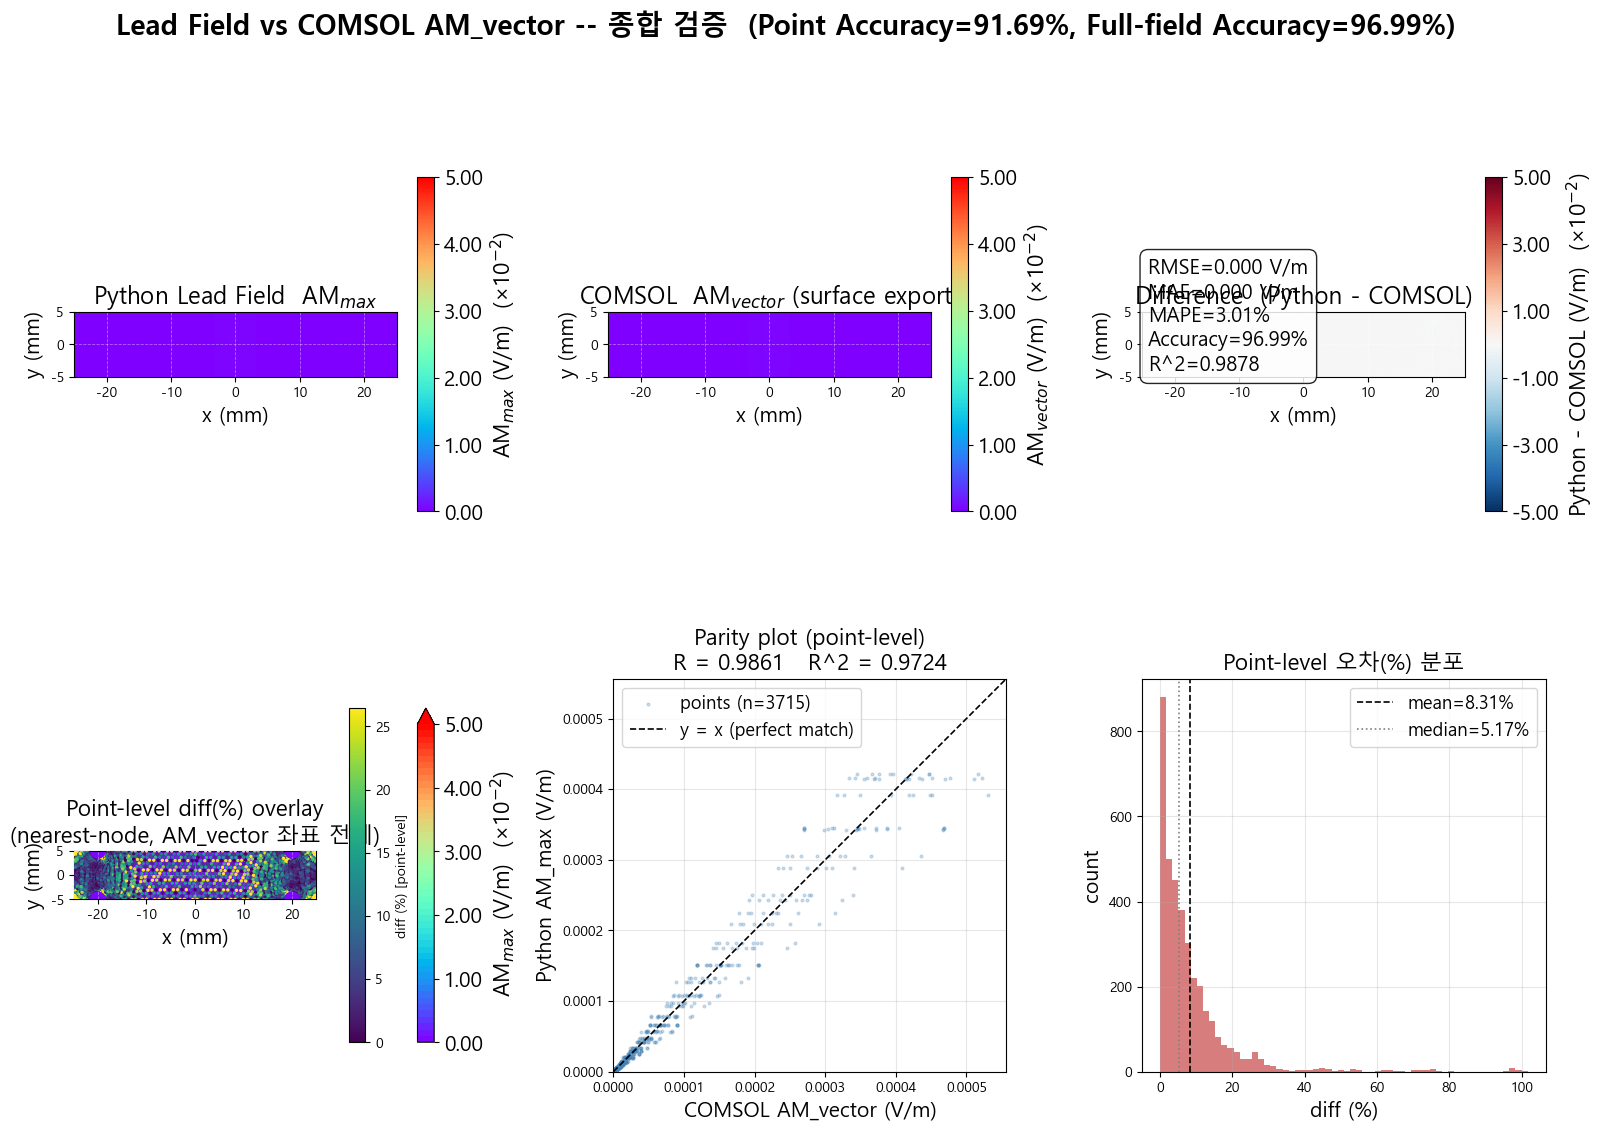

In [496]:
# ── COMSOL AM_vector surface export 로드 (한 번만 — point-level/full-field 공용) ──
df_comsol_am = pd.read_csv(AM_VECTOR_FILE, comment="%", header=None,
                            names=["x", "y", "AM_vector"])
comsol_xy = df_comsol_am[["x", "y"]].values
comsol_am = df_comsol_am["AM_vector"].values
print(f"COMSOL AM_vector 좌표 수: {len(comsol_am)}  범위: [{comsol_am.min():.4f}, {comsol_am.max():.4f}] V/m")

# ── lead field → Python AM_max (Grossman) ────────────────────────────────────
val_coords, val_Ef1_tensor = load_leadfield_2d(LEADFIELD_F1)
_,          val_Ef2_tensor = load_leadfield_2d(LEADFIELD_F2)
val_Ef1 = val_Ef1_tensor[0] - val_Ef1_tensor[1]
val_Ef2 = val_Ef2_tensor[0] - val_Ef2_tensor[1]
val_AM  = compute_AM_Grossman(val_Ef1, val_Ef2)


# ═══════════════════════════════════════════════════════════════════════════
# 방법 A — Point-level: AM_vector 좌표마다 nearest Python leadfield 노드 매칭
#          (mesh 대 mesh 직접 비교, 보간 없음 → 실제 값 오차)
# ═══════════════════════════════════════════════════════════════════════════
tree = cKDTree(val_coords)
nn_dist, nn_idx = tree.query(comsol_xy)

python_am_matched = val_AM[nn_idx]
diff_abs_pt = python_am_matched - comsol_am
diff_pct_pt = np.divide(
    np.abs(diff_abs_pt), np.abs(comsol_am),
    out=np.full_like(comsol_am, np.nan), where=np.abs(comsol_am) > 1e-9,
) * 100

df_val = pd.DataFrame({
    "x (mm)": comsol_xy[:, 0], "y (mm)": comsol_xy[:, 1],
    "COMSOL_AM (V/m)": comsol_am, "Python_AM (V/m)": python_am_matched,
    "diff (V/m)": diff_abs_pt, "diff (%)": diff_pct_pt, "nn_dist (mm)": nn_dist,
})

rmse_pt = np.sqrt(np.mean(diff_abs_pt ** 2))
mae_pt  = np.mean(np.abs(diff_abs_pt))
mape_pt = np.nanmean(diff_pct_pt)
acc_pt  = 100 - mape_pt
corr_pt = np.corrcoef(python_am_matched, comsol_am)[0, 1]
r2_pt   = corr_pt ** 2

print(f"\n[방법 A: Point-level, nearest-node]  n={len(df_val)}  "
      f"nn_dist max={nn_dist.max():.3f} mm  mean={nn_dist.mean():.3f} mm")
print(df_val["diff (%)"].describe())
print("\n오차 상위 10개 좌표:")
display(df_val.sort_values("diff (%)", ascending=False).head(10).round(6))


# ═══════════════════════════════════════════════════════════════════════════
# 방법 B — Full-field: 공통 정규 격자에 보간 후 비교 (공간 분포/패턴 비교용)
# ═══════════════════════════════════════════════════════════════════════════
GRID_RES = 200
xg_min = max(val_coords[:, 0].min(), comsol_xy[:, 0].min())
xg_max = min(val_coords[:, 0].max(), comsol_xy[:, 0].max())
yg_min = max(val_coords[:, 1].min(), comsol_xy[:, 1].min())
yg_max = min(val_coords[:, 1].max(), comsol_xy[:, 1].max())

xi = np.linspace(xg_min, xg_max, GRID_RES)
yi = np.linspace(yg_min, yg_max, GRID_RES)
Xi, Yi = np.meshgrid(xi, yi)

python_grid = griddata(val_coords, val_AM, (Xi, Yi), method="linear")
comsol_grid = griddata(comsol_xy, comsol_am, (Xi, Yi), method="linear")
diff_grid   = python_grid - comsol_grid

valid_mask = ~(np.isnan(diff_grid) | np.isnan(python_grid) | np.isnan(comsol_grid))
p_valid, c_valid, d_valid = python_grid[valid_mask], comsol_grid[valid_mask], diff_grid[valid_mask]

rmse_gd = np.sqrt(np.mean(d_valid ** 2))
mae_gd  = np.mean(np.abs(d_valid))
nz      = np.abs(c_valid) > 1e-9
mape_gd = np.mean(np.abs(d_valid[nz]) / np.abs(c_valid[nz])) * 100
acc_gd  = 100 - mape_gd
corr_gd = np.corrcoef(p_valid, c_valid)[0, 1]
r2_gd   = corr_gd ** 2

print(f"\n[방법 B: Full-field, grid interpolation]  grid={GRID_RES}x{GRID_RES}")
print(f"  RMSE={rmse_gd:.4f} V/m  MAE={mae_gd:.4f} V/m  MAPE={mape_gd:.2f}%  "
      f"Accuracy={acc_gd:.2f}%  R={corr_gd:.4f}  R^2={r2_gd:.4f}")

# ── 두 방법 교차검증 (critical check) ─────────────────────────────────────────
print("\n─── 두 방법 비교 (교차 검증) ───")
print(f"{'metric':10s} {'Point(A)':>12s} {'Grid(B)':>12s} {'diff':>10s}")
for name, a, b in [("RMSE", rmse_pt, rmse_gd), ("MAE", mae_pt, mae_gd),
                    ("MAPE%", mape_pt, mape_gd), ("Accuracy%", acc_pt, acc_gd),
                    ("R^2", r2_pt, r2_gd)]:
    print(f"{name:10s} {a:12.4f} {b:12.4f} {a - b:10.4f}")
if abs(acc_pt - acc_gd) > 5:
    print("[주의] 두 방법의 정확도 차이가 5%p 이상 — griddata 보간 스무딩 또는 "
          "mesh 해상도 차이로 인한 인공적 오차 가능성 점검 필요")
else:
    print("→ 두 방법이 서로 일관된 정확도를 보고함: 결과 신뢰 가능")


# ═══════════════════════════════════════════════════════════════════════════
# 종합 시각화 — 2행 3열
#  Row1: Full-field  [Python | COMSOL | Diff]
#  Row2: 진단        [Point diff% overlay | Parity plot | Error histogram]
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(19, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.32)

VMIN, VMAX = 0, 0.05   # 조건 간 객관적 비교를 위해 colorbar range 고정
vmax_field = VMAX

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.pcolormesh(Xi, Yi, python_grid, cmap="rainbow", vmin=VMIN, vmax=VMAX, shading="auto")
cb1 = fig.colorbar(im1, ax=ax1, shrink=0.85, label="AM$_{max}$ (V/m)")
apply_sci_colorbar(cb1, VMIN, VMAX)
ax1.set_title("Python Lead Field  AM$_{max}$", fontsize=17)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.pcolormesh(Xi, Yi, comsol_grid, cmap="rainbow", vmin=VMIN, vmax=VMAX, shading="auto")
cb2 = fig.colorbar(im2, ax=ax2, shrink=0.85, label="AM$_{vector}$ (V/m)")
apply_sci_colorbar(cb2, VMIN, VMAX)
ax2.set_title("COMSOL  AM$_{vector}$ (surface export)", fontsize=17)

# diff colorbar 범위를 field 범위(vmax_field)에 맞춤 → 두 필드가 유사한 스케일임이 시각적으로 드러남
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.pcolormesh(Xi, Yi, diff_grid, cmap="RdBu_r", vmin=-vmax_field, vmax=vmax_field, shading="auto")
cb3 = fig.colorbar(im3, ax=ax3, shrink=0.85, label="Python - COMSOL (V/m)")
apply_sci_colorbar(cb3, -vmax_field, vmax_field)
ax3.set_title("Difference  (Python - COMSOL)", fontsize=17)
ax3.text(0.02, 0.02,
         f"RMSE={rmse_gd:.3f} V/m\nMAE={mae_gd:.3f} V/m\nMAPE={mape_gd:.2f}%\n"
         f"Accuracy={acc_gd:.2f}%\nR^2={r2_gd:.4f}",
         transform=ax3.transAxes, fontsize=14.5, va="bottom", ha="left",
         bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.85))

for ax in (ax1, ax2, ax3):
    ax.set_xlabel("x (mm)", fontsize=15); ax.set_ylabel("y (mm)", fontsize=15)
    ax.set_aspect("equal")
    ax.grid(True, color="white", alpha=0.4, linewidth=0.6, linestyle="--", zorder=4)

# (2,1) Point-level diff% overlay
ax4 = fig.add_subplot(gs[1, 0])
triang_val = mtri.Triangulation(x, y)
tcf = ax4.tricontourf(triang_val, AM_max, levels=np.linspace(VMIN, VMAX, 51),
                      cmap="rainbow", vmin=VMIN, vmax=VMAX, extend="max")
cb4 = fig.colorbar(tcf, ax=ax4, shrink=0.85, label="AM$_{max}$ (V/m)")
apply_sci_colorbar(cb4, VMIN, VMAX)
diff_vmax_pt = np.nanpercentile(df_val["diff (%)"], 95)
sc = ax4.scatter(df_val["x (mm)"], df_val["y (mm)"], c=df_val["diff (%)"],
                  cmap="viridis", s=6, vmin=0, vmax=diff_vmax_pt, edgecolors="none", zorder=10)
fig.colorbar(sc, ax=ax4, shrink=0.85, pad=0.1, label="diff (%) [point-level]")
ax4.set_title("Point-level diff(%) overlay\n(nearest-node, AM_vector 좌표 전체)", fontsize=16)
ax4.set_xlabel("x (mm)", fontsize=15); ax4.set_ylabel("y (mm)", fontsize=15)
ax4.set_aspect("equal")
ax4.grid(True, color="white", alpha=0.4, linewidth=0.6, linestyle="--", zorder=4)

# (2,2) Parity plot — COMSOL vs Python (y=x)
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(df_val["COMSOL_AM (V/m)"], df_val["Python_AM (V/m)"],
            s=4, alpha=0.25, color="steelblue", label=f"points (n={len(df_val)})")
lims = [0, max(df_val["COMSOL_AM (V/m)"].max(), df_val["Python_AM (V/m)"].max()) * 1.05]
ax5.plot(lims, lims, "k--", lw=1.2, label="y = x (perfect match)")
ax5.set_xlim(lims); ax5.set_ylim(lims)
ax5.set_xlabel("COMSOL AM_vector (V/m)", fontsize=15)
ax5.set_ylabel("Python AM_max (V/m)", fontsize=15)
ax5.set_title(f"Parity plot (point-level)\nR = {corr_pt:.4f}   R^2 = {r2_pt:.4f}", fontsize=16)
ax5.legend(fontsize=13, loc="upper left")
ax5.set_aspect("equal")
ax5.grid(True, alpha=0.3)

# (2,3) Error histogram
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(df_val["diff (%)"].dropna(), bins=60, color="indianred", alpha=0.8)
ax6.axvline(mape_pt, color="black", ls="--", lw=1.2, label=f"mean={mape_pt:.2f}%")
ax6.axvline(np.nanmedian(df_val["diff (%)"]), color="gray", ls=":", lw=1.2,
            label=f"median={np.nanmedian(df_val['diff (%)']):.2f}%")
ax6.set_xlabel("diff (%)", fontsize=15)
ax6.set_ylabel("count", fontsize=15)
ax6.set_title("Point-level 오차(%) 분포", fontsize=16)
ax6.legend(fontsize=13)
ax6.grid(True, alpha=0.3)

fig.suptitle(
    f"Lead Field vs COMSOL AM_vector -- 종합 검증  "
    f"(Point Accuracy={acc_pt:.2f}%, Full-field Accuracy={acc_gd:.2f}%)",
    fontsize=20, fontweight="bold", y=0.995,
)
plt.tight_layout()
val_save = SIM_DIR / f"Result_Efield_validation_{TAG}.png"
plt.savefig(val_save, dpi=150, bbox_inches="tight")
print(f"\nSaved: {val_save.resolve()}")
plt.show()

## 6. CSV 저장

In [497]:
out_path = SIM_DIR / f"Result_Efield_magnitude_result_{TAG}.csv"
df_result.to_csv(out_path, index=False)
print(f"Saved: {out_path.resolve()}")
df_result.describe()

Saved: D:\00_Project\nTIS\docs\07_Simulation\Result\Result_Efield_magnitude_result_CompactY_X50_Y10.csv


,x (mm),y (mm),Ex_f1 (V/m),Ey_f1 (V/m),|E_f1| (V/m),Ex_f2 (V/m),Ey_f2 (V/m),|E_f2| (V/m),AM_max (V/m)
count,451.000000,451.000000,4.510000e+02,4.510000e+02,4.510000e+02,4.510000e+02,4.510000e+02,4.510000e+02,4.510000e+02
mean,0.070531,0.025223,-5.317282e-04,-2.291446e-02,3.011608e-02,-7.353674e-04,-2.316004e-02,3.043507e-02,1.773485e-05
std,18.767676,3.158564,2.711812e-02,3.336142e-02,3.828715e-02,2.744585e-02,3.327398e-02,3.834321e-02,6.125537e-05
min,-25.000000,-5.000000,-9.887191e-02,-1.270427e-01,9.116514e-10,-9.888484e-02,-1.274581e-01,7.554477e-10,1.510895e-09
25%,-19.021852,-2.918379,-1.561816e-04,-4.735812e-02,6.044088e-07,-2.303309e-04,-4.740202e-02,5.870844e-07,8.883862e-07
50%,0.907097,-0.085785,-2.241848e-09,-5.997661e-06,1.722137e-04,-1.036482e-09,-1.771592e-05,2.843491e-04,1.201962e-06
75%,18.910372,2.999187,3.988284e-05,-3.570049e-07,6.733050e-02,6.038327e-05,-3.536709e-07,6.728809e-02,3.165065e-06
max,25.000000,5.000000,9.934543e-02,1.640231e-04,1.270435e-01,9.935540e-02,1.838650e-04,1.274588e-01,4.210602e-04
